### Imports and Setup

In [1]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.notebook import tqdm

from whale_gunshot_localization import config

### Generate Synthetic Measurements

Functions to randomly generate the measurements/sources/associations and visualize the results

In [55]:
def generate_measurements(num_sources, var=10, num_delete=0, seed=1111):
    """
    Generate some synthetic measurements to test with data association/localization algoritms.
    
    Parameters
    ----------
    num_sources : int
        maximum number of sources
    var : float
        variance of Gaussian perturbation to range measurements
    num_delete : int
        maximum number of measurements to hide/delete at each TOSSIT
    seed : int
        seed for RNG
        
    Returns
    -------
    range_measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """ 
    
    # get TOSSIT locations and extreme coordinate values
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']

    # instantiate random number generator
    rng = np.random.default_rng(seed)
    
    # choose number of sources
    n = rng.choice(np.arange(num_sources))

    # generate source locations
    source_locs = np.concatenate((rng.uniform(min_y, max_y, size=(n,1)), rng.uniform(min_x, max_x, size=(n,1))), axis=1)

    # range measurements and associations
    range_measurements = [(np.linalg.norm(source_locs - TOSSIT_locations[t,:], axis=1) + rng.normal(loc=0, scale=np.sqrt(var), size=n)) for t in range(TOSSIT_locations.shape[0])]
    source_associations = [(np.arange(n)) for _ in range(TOSSIT_locations.shape[0])]
    TOSSIT_associations = [np.ones((n,), dtype=int)*t for t in range(TOSSIT_locations.shape[0])]
    
    # generate number of measurements for each source to delete
    if num_delete > 0:
        del_list = rng.choice(np.arange(num_delete+1), size=TOSSIT_locations.shape[0])
        
    # delete measurements and associations
    for i, (m, a, t, d) in enumerate(zip(range_measurements, source_associations, TOSSIT_associations, del_list)):
        if d:
            del_idx = rng.choice(np.arange(n), replace=False, size=d)
            range_measurements[i] = np.delete(m, del_idx)
            source_associations[i] = np.delete(a, del_idx)
            TOSSIT_associations[i] = np.delete(t, del_idx)
    
    # make sure smallest association value is 0
    bias = min([a[0] for a in source_associations])
    if bias > 0:
        for i, a in enumerate(source_associations):
            source_associations[i] = a - bias
    
    return range_measurements, source_associations, TOSSIT_associations, source_locs

def visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs):
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # plot sources and sensor locations
    plt.figure()
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', label='sensor', markersize=12, markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='source')

    # get unique colors for each source
    color_list = [rng.uniform(0, 1, size=3) for _ in range(len(max(measurements, key=lambda x:len(x))))]
    # get group of measurements, associated TOSSITs, and associated sources
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # for each measurement, draw line between associated TOSSIT and source
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            plt.plot([TOSSIT_locations[tt,1], source_locs[aa,1]], [TOSSIT_locations[tt,0], source_locs[aa,0]], '--', color=color_list[aa])
    
    # final touches on plot
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Ideal Measurements/Associations")
    plt.legend(["sensor", "source", "source range measurement"],bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

def visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs, buffer=10000, figsize=(5,20)):
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']
    
    fig, axs = plt.subplots(source_locs.shape[0],1, figsize=figsize)
    ag_fig = plt.figure()
    ag_fig.add_subplot(111)
    ag_ax = ag_fig.axes[0]
    
    # plot associated measurements
    color_list = [rng.uniform(0, 1, size=3) for _ in range(len(max(measurements, key=lambda x:len(x))))]
    a_is_labeled = np.zeros((source_locs.shape[0],))
    a_ag_labeled = False
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # plot sources and sensor locations
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            
            # plot range measurement
            circle1 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_is_labeled[aa] else None)
            circle2 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_ag_labeled else None)
            axs[aa].add_artist(circle1)
            ag_ax.add_artist(circle2)
            
            # keep track of if we have a labeled measurement
            # for each assocaition.
            if not a_is_labeled[aa]:
                a_is_labeled[aa] = 1
                a_ag_labeled = True
    
    # plot common elements among subplots
    
    for i, ax in enumerate(list(axs) + [ag_ax]):
        ax.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
        ax.set_xlabel("X [m]")
        ax.set_ylabel("Y [m]")
        ax.set_xlim([min_x-buffer, max_x+buffer])
        ax.set_ylim([min_y-buffer, max_y+buffer])
        for a in range(source_locs.shape[0]):
            ax.plot(source_locs[a,1], source_locs[a,0], 'o', color=color_list[a], label='source' if a == 0 else None)
        ax.invert_yaxis()
        if i == source_locs.shape[0]:
            ag_ax.set_title("Aggregate Measurement/Association Visualization")
        else:
            ax.set_title("Measurement/Association Visualization")
        
        # set up legend
        handles, labels = ax.get_legend_handles_labels()
        order = [1,2,0]
        ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1.0), loc='upper left')
        leg = ax.get_legend()
        leg.legendHandles[1].set_color('black')
        leg.legendHandles[2].set_color('black')
    plt.show()

Generate the measurements

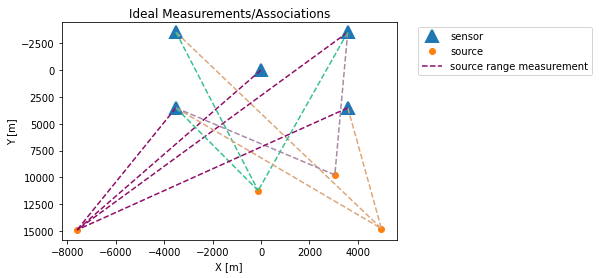

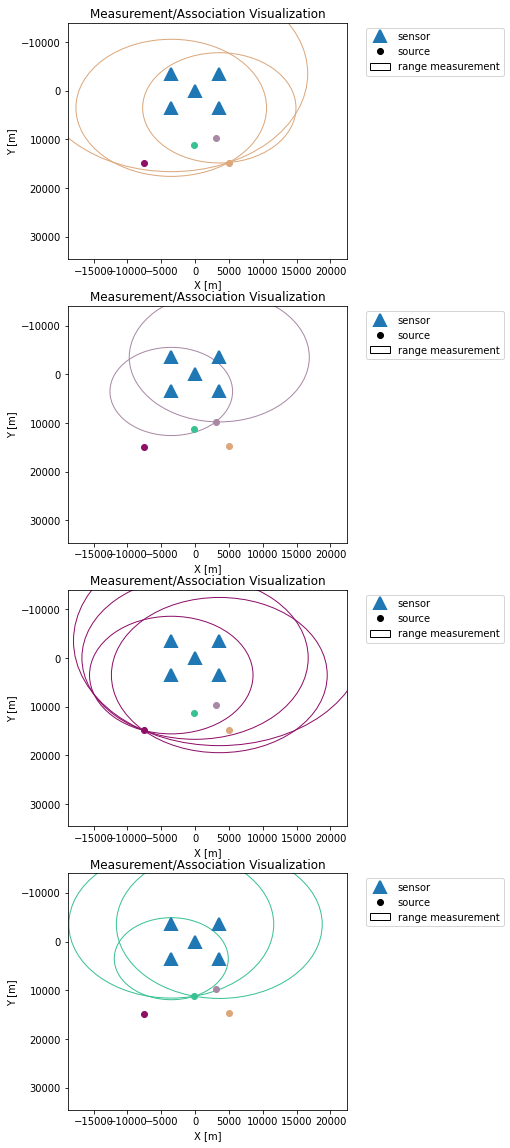

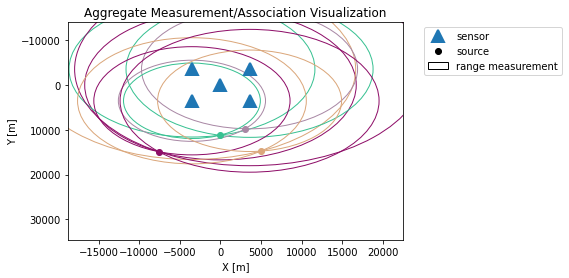

In [57]:
# generate measurements and associations
measurements, source_associations, TOSSIT_associations, source_locs = generate_measurements(num_sources=5, var=0, num_delete=3)

# visualize results
visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs)
print(100*"=")
visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs)

### A RANSAC Approach
Using RANSAC to simultaneously perform data association and localization

In [673]:
def point_circle_shortest_distance(center, r, point):
    """
    Calculate shortest distance between a given point and circle
    """
    
    return np.abs(np.sqrt(((center - point) ** 2).sum()) - r)

def RANSAC(measurements, n):

    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    idx = np.arange(TOSSIT_locations.shape[0])
    
    # get bounds on grid
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # save associated measurements
    saves = []
    
    for _ in tqdm(range(n)):
        i = np.random.choice(idx, replace=False, size=4)
        combs = np.asarray(list(itertools.product(measurements[i[0]], measurements[i[1]], measurements[i[2]], measurements[i[3]])))
        sample_idx = np.random.choice(np.arange(len(combs)))
        sample = combs[sample_idx]
        
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((TOSSIT_locations[i,0] - x[0]) ** 2 + (TOSSIT_locations[i,1] - x[1]) ** 2)

            # return sum squared error between l2s and predicted ranges
            return (1/4)*np.sum((l2.squeeze() - sample) ** 2)
        
        # random initial guess
        init_x = np.random.uniform(min_x, max_x)
        init_y = np.random.uniform(min_y, max_y)
        
        # optimize 
        res = minimize(obj, [init_y, init_x], method='Nelder-Mead', options={'disp': False})
        
        # check for associated data
        if np.sqrt(res.fun) < 150:
            if (set(i), set(sample)) not in saves:
                print(i, sample, res.fun, res.x)
                saves.append((set(i), set(sample)))
        
    return saves

In [674]:
saves = RANSAC(measurements, 2000)

  0%|          | 0/2000 [00:00<?, ?it/s]

Convert results to format for visualization

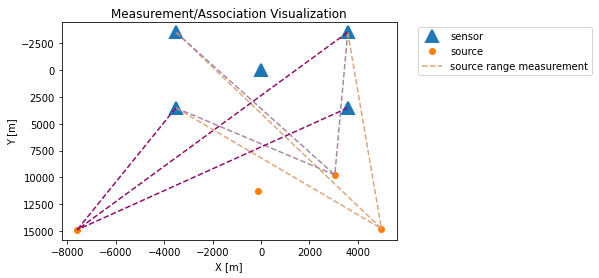

In [380]:
m_opt = [[] for _ in range(len(measurements))]
a_opt = [[] for _ in range(len(associations))]

a_num = 0
for s in saves:
    for t, m in zip(s[0], s[1]):
        m_opt[t].append(m)
        a_opt[t].append(a_num)
    a_num += 1
    
m_opt = [np.asarray(elem) for elem in m_opt]
a_opt = [np.asarray(elem) for elem in a_opt]

visualize_measurements(m_opt, a_opt, source_locs)